In [ ]:
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn nltk

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/My Drive/Datasets/Phishing_Email.csv'
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [ ]:
df['Email Text'] = df['Email Text'].fillna('')

In [ ]:
print(df['Email Text'].iloc[0])
print([c for c in df['Email Text'].iloc[0]])

re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure that it is fair to attribute this to " sons " being " treated like senior relatives " . for one thing , we do n't normally use ' brother ' in this way any more than we do 'd aughter ' , and it is hard to imagine a natural class comprising senior relatives and 's on ' but excluding ' brother ' . for another , there seem to me to be differences here . if i am not imagining a distinction that is not there , it seems to me that the senior relative terms are used in a wider variety of contexts , e . g . , calling out from a distance to get someone 's attention , and hence at the beginning of an utterance , whereas 's on ' seems more natural in utterances like ' yes , son ' , ' hand me that , son ' than in ones like ' son ! ' or ' son , help me ! ' ( although perhaps these latter ones are not compl

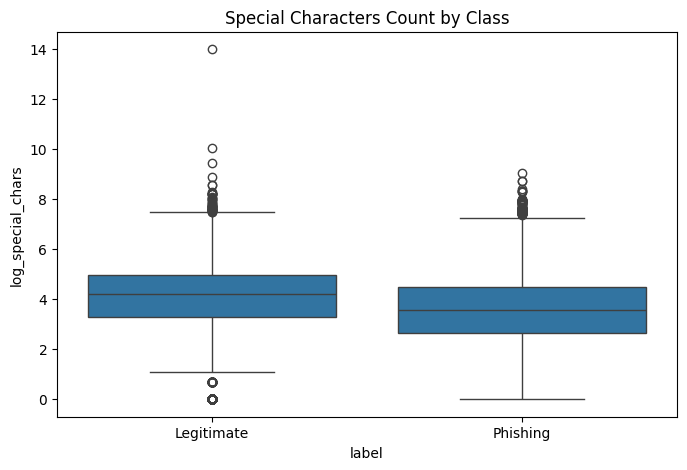

In [ ]:
import re

df['special_chars'] = df['Email Text'].apply(
    lambda x: len(re.findall(r'[^a-zA-Z0-9\s]', str(x)))
)
df['log_special_chars'] = np.log1p(df['special_chars'])

df["label"] = df["Email Type"].map({"Safe Email": 0, "Phishing Email": 1})

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='log_special_chars', data=df)

plt.xticks([0,1], ['Legitimate','Phishing'])
plt.title("Special Characters Count by Class")
plt.show()

In [ ]:
import re
from nltk.corpus import stopwords

# Get phishing emails
phishing_text = df[df['label'] == 1]['Email Text']

# Combine text
all_text = " ".join(phishing_text.astype(str))

# Step 1: Extract URLs
urls = re.findall(r'https?://\S+', all_text)

# Step 2: Extract clean words (no symbols)
words = re.findall(r'\b[a-zA-Z]+\b', all_text)

# Step 3: Remove stopwords
stop_words = set(stopwords.words('english'))

filtered_words = [
    word.lower() for word in words
    if word.lower() not in stop_words and len(word) > 2
]

# Step 4: Combine words + URLs
final_tokens = filtered_words + urls

# Check
print(final_tokens[:50])

['hello', 'hot', 'lil', 'horny', 'toy', 'one', 'dream', 'open', 'minded', 'person', 'love', 'talk', 'subject', 'fantasy', 'way', 'life', 'ultimate', 'sex', 'play', 'ummmmmmmmmmmmmm', 'wet', 'ready', 'looks', 'imagination', 'matters', 'sexy', 'voice', 'make', 'dream', 'come', 'true', 'hurry', 'call', 'let', 'cummmmm', 'toll', 'free', 'teen', 'phone', 'billing', 'sign', 'free', 'personalized', 'mail', 'mail', 'com', 'http', 'www', 'mail', 'com']


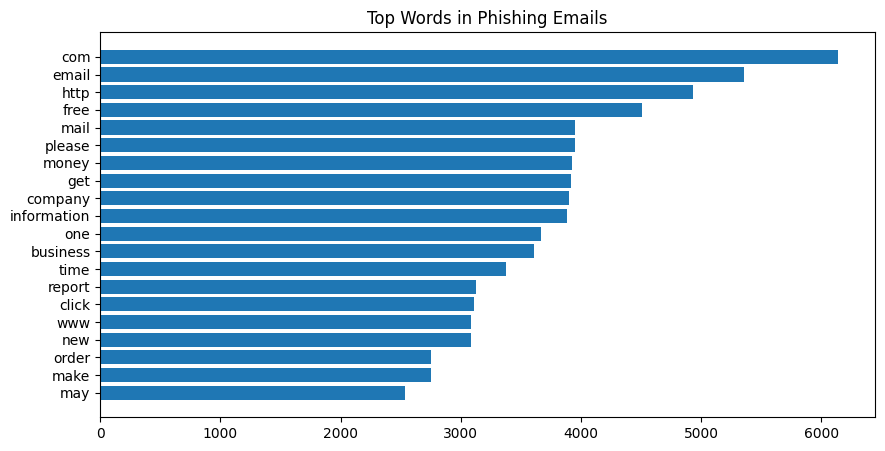

In [ ]:
from collections import Counter

word_counts = Counter(filtered_words)

common_words = word_counts.most_common(20)

words, counts = zip(*common_words)

plt.figure(figsize=(10,5))
plt.barh(words, counts)
plt.gca().invert_yaxis()
plt.title("Top Words in Phishing Emails")
plt.show()

In [ ]:
X = df['Email Text']   # check your column name
y = df['Email Type']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report for logisticRegression:\n", classification_report(y_test, y_pred))

Accuracy: 0.958541815582559

Classification Report for logisticRegression:
                 precision    recall  f1-score   support

Phishing Email       0.95      0.95      0.95      1111
    Safe Email       0.97      0.97      0.97      1687

      accuracy                           0.96      2798
     macro avg       0.96      0.96      0.96      2798
  weighted avg       0.96      0.96      0.96      2798



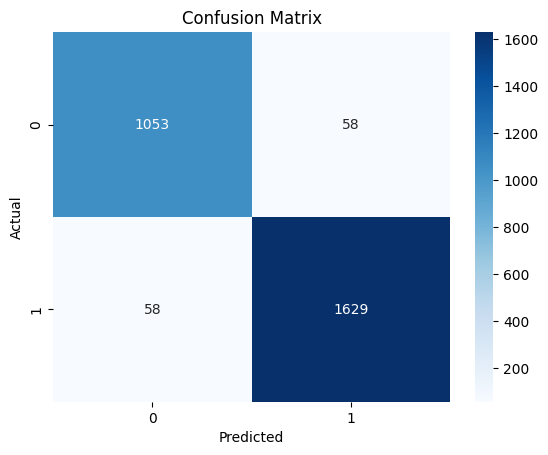

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.953180843459614

Classification Report:
                 precision    recall  f1-score   support

Phishing Email       0.94      0.94      0.94      1111
    Safe Email       0.96      0.96      0.96      1687

      accuracy                           0.95      2798
     macro avg       0.95      0.95      0.95      2798
  weighted avg       0.95      0.95      0.95      2798



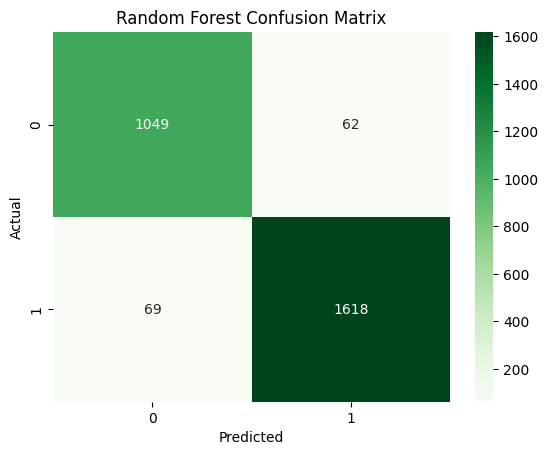

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

For distilbert
